# <font color='439ADF'> **"Cyclistic" Case Study** </font>

# <font color='439ADF'> **1. Introduction** </font>

## **About Dataset**

This dataset belongs to the "Cyclistic" practical case study, which is part of the capstone project for the Google Data Analytics Professional Certificate. The goal of the analysis is to understand how casual riders and annual members use the bikes differently in order to design a marketing strategy aimed at converting riders into members.

## **Data Origin and Attribution**

The original raw data consists of actual bicycle trip records from Motivate International Inc. (operator of the Divvy system in Chicago). The data has been processed and made publicly available under this Data Use License Agreement.

**Period covered in this repository:** June 2025 to May 2026 (12 months of historical data).

**Purpose:** Exclusively academic and for data analysis portfolio demonstration.

# <font color='439ADF'> **2. Data Preparation & Processing** </font> #

##**Data extraction**

In [1]:
# 1. CREDENTIALS CONFIGURATION
# Paste your raw Kaggle API Key inside the single quotes below.
KAGGLE_CREDENTIALS = '{"username":"________","key":"________________________________"}'

# 2. DATASET CONFIGURATION
# Example: "username/dataset-name"
DATASET_CONFIG = "santiagop25/cyclistic-bike-share-case-study-2025-2026"

# AUTOMATIC DOWNLOAD AND EXTRACTION PROCESS
!pip install -q kaggle
import os
import zipfile
import glob

# Create the hidden directory for Kaggle configuration
!mkdir -p ~/.kaggle

# Write credentials directly to the system's internal configuration file
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    f.write(KAGGLE_CREDENTIALS)

# Restrict file permissions for security (Read/Write for owner only)
!chmod 600 ~/.kaggle/kaggle.json

# Clean text variables
DATASET_CONFIG = DATASET_CONFIG.strip()
dataset_base_name = DATASET_CONFIG.split("/")[-1]
zip_filename = dataset_base_name + ".zip"

print(f"Starting download from Kaggle: {DATASET_CONFIG}...")
download_status = os.system(f'kaggle datasets download -d {DATASET_CONFIG}')

if download_status != 0:
    print("\n[ERROR] The download failed. Please verify that:")
    print("1. Your API Key was copied correctly, including the curly braces { }.")
    print("2. The username and repository in 'DATASET_CONFIG' match the URL.")
else:
    extraction_path = "./datos_raw_cyclistic"
    if os.path.exists(zip_filename):
        print(f"\nExtracting {zip_filename} to '{extraction_path}'...")
        with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
            zip_ref.extractall(extraction_path)

        os.remove(zip_filename) # Free up temporary disk space
        extracted_csvs = glob.glob(os.path.join(extraction_path, "*.csv"))
        print(f"\nProcess Completed Successfully!")
        print(f"Extracted {len(extracted_csvs)} CSV files ready for merging.")
    else:
        print(f"\n[ERROR] Compressed ZIP file not found.")

Starting download from Kaggle: santiagop25/cyclistic-bike-share-case-study-2025-2026...

Extracting cyclistic-bike-share-case-study-2025-2026.zip to './datos_raw_cyclistic'...

Process Completed Successfully!
Extracted 12 CSV files ready for merging.


In [2]:
import pandas as pd
import glob
import os

# Define the directory where the CSV files were extracted
csv_path = "./datos_raw_cyclistic"
csv_files = glob.glob(os.path.join(csv_path, "*.csv"))

# Sort the files chronologically/alphabetically for visual tracking
csv_files.sort()
print(f"Found {len(csv_files)} monthly files to consolidate.\n")

# List to store the DataFrames for each month
monthly_dfs = []

# Loop through and load each file into memory
for archive in csv_files:
    filename = os.path.basename(archive)
    print(f"-> Loading into memory: {filename}")

    # Read the monthly CSV file
    df_month = pd.read_csv(archive)
    monthly_dfs.append(df_month)

# Concatenate all individual DataFrames into a single master DataFrame
print("\nMerging all monthly data into the master DataFrame...")
df_cyclistic = pd.concat(monthly_dfs, ignore_index=True)

# EXTRACTION SUMMARY REPORT
print("\n--- EXTRACTION SUMMARY ---")
print(f"Total consolidated records: {df_cyclistic.shape[0]:,}")
print(f"Total columns: {df_cyclistic.shape[1]}")

Found 12 monthly files to consolidate.

-> Loading into memory: 202506-divvy-tripdata.csv
-> Loading into memory: 202507-divvy-tripdata.csv
-> Loading into memory: 202508-divvy-tripdata.csv
-> Loading into memory: 202509-divvy-tripdata.csv
-> Loading into memory: 202510-divvy-tripdata.csv
-> Loading into memory: 202511-divvy-tripdata.csv
-> Loading into memory: 202512-divvy-tripdata.csv
-> Loading into memory: 202601-divvy-tripdata.csv
-> Loading into memory: 202602-divvy-tripdata.csv
-> Loading into memory: 202603-divvy-tripdata.csv
-> Loading into memory: 202604-divvy-tripdata.csv
-> Loading into memory: 202605-divvy-tripdata.csv

Merging all monthly data into the master DataFrame...

--- EXTRACTION SUMMARY ---
Total consolidated records: 5,848,703
Total columns: 13


### **Dataframe information**

In [3]:
df_cyclistic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5848703 entries, 0 to 5848702
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 580.1+ MB


### **Printout of the dataframe**

In [4]:
df_cyclistic.head(15)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,0E43949BF937C7DA,electric_bike,2025-06-05 21:24:56.104,2025-06-05 21:38:44.446,Clark St & Armitage Ave,CHI00474,Dearborn Pkwy & Delaware Pl,CHI00306,41.918306,-87.636282,41.898969,-87.629912,member
1,1CDEA40FEAF21789,classic_bike,2025-06-14 13:03:34.478,2025-06-14 13:13:19.791,Dearborn Pkwy & Delaware Pl,CHI00306,Kingsbury St & Kinzie St,CHI00299,41.898969,-87.629912,41.889177,-87.638506,member
2,7ECEB1638575575C,classic_bike,2025-06-09 13:30:22.540,2025-06-09 13:39:53.640,Dearborn Pkwy & Delaware Pl,CHI00306,Kingsbury St & Kinzie St,CHI00299,41.898969,-87.629912,41.889177,-87.638506,member
3,F275084E25F5A131,electric_bike,2025-06-15 12:48:13.321,2025-06-15 13:00:18.798,Clark St & Elm St,CHI00281,NaN,NaN,41.902970,-87.631300,41.920000,-87.650000,member
4,F42E81C85AC722FB,electric_bike,2025-06-19 07:54:26.103,2025-06-19 08:04:36.583,Damen Ave & Cortland St,CHI00388,NaN,NaN,41.915983,-87.677335,41.940000,-87.690000,member
5,6EEC90FDF82096A9,electric_bike,2025-06-17 19:06:40.626,2025-06-17 19:19:26.412,Sheffield Ave & Wellington Ave,CHI00274,NaN,NaN,41.936253,-87.652662,41.910000,-87.630000,member
6,26E86CA213DF47DD,classic_bike,2025-06-16 14:31:16.892,2025-06-16 14:34:14.641,Western Ave & Leland Ave,CHI00435,Campbell Ave & Montrose Ave,CHI00214,41.965720,-87.688440,41.961524,-87.691177,member
7,8862F2F1B6224109,electric_bike,2025-06-18 23:25:12.745,2025-06-18 23:51:53.896,Laflin St & Cullerton St,CHI00352,NaN,NaN,41.854915,-87.663560,41.890000,-87.620000,member
8,CA21D68E6F04E0DE,electric_bike,2025-06-06 16:53:06.560,2025-06-06 17:09:19.530,Damen Ave & Cortland St,CHI00388,NaN,NaN,41.915983,-87.677335,41.900000,-87.620000,casual
9,A7BEA2FE9708F666,electric_bike,2025-06-05 21:38:57.402,2025-06-05 21:42:43.545,Sheridan Rd & Noyes St (NU),CHI01114,NaN,NaN,42.058239,-87.677432,42.050000,-87.680000,casual


## **Data transformation**

In [5]:
import pandas as pd
import numpy as np

print("Starting transformation and feature engineering phase...")

# 1. DATETIME FORMAT CONVERSION
# Ensure that datetime columns are explicitly parsed into datetime objects
df_cyclistic['started_at'] = pd.to_datetime(df_cyclistic['started_at'])
df_cyclistic['ended_at'] = pd.to_datetime(df_cyclistic['ended_at'])

# 2. METRIC CALCULATION & TEMPORAL COMPONENTS
print("Calculating temporal components for seasonality analysis...")

# Calculate ride duration in minutes (essential for direct numerical aggregations)
df_cyclistic['ride_length_mins'] = (df_cyclistic['ended_at'] - df_cyclistic['started_at']).dt.total_seconds() / 60

# Extract time dimensions for deep pattern recognition
df_cyclistic['day_name'] = df_cyclistic['started_at'].dt.day_name()    # Day of the week (Monday, Sunday, etc.)
df_cyclistic['month_name'] = df_cyclistic['started_at'].dt.month_name()  # Month of the year
df_cyclistic['hour_of_day'] = df_cyclistic['started_at'].dt.hour        # Hour of the day (0-23)

# 3. ANOMALY CLEANING & DATA INTEGRITY
print("Removing inconsistent records...")
records_before = df_cyclistic.shape[0]

# Filter: Remove trips where numerical duration is less than or equal to 0 minutes
df_cyclistic = df_cyclistic[df_cyclistic['ride_length_mins'] > 0]

records_after = df_cyclistic.shape[0]

print(f"\nRecords removed due to time inconsistencies (<= 0 mins): {records_before - records_after:,}")
print(f"Total clean records ready for analysis: {df_cyclistic.shape[0]:,}")
print("-" * 80)

# 4. PREVIEW PROCESSED DATASET
df_cyclistic.head()

Starting transformation and feature engineering phase...
Calculating temporal components for seasonality analysis...
Removing inconsistent records...

Records removed due to time inconsistencies (<= 0 mins): 29
Total clean records ready for analysis: 5,848,674
--------------------------------------------------------------------------------


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length_mins,day_name,month_name,hour_of_day
0,0E43949BF937C7DA,electric_bike,2025-06-05 21:24:56.104,2025-06-05 21:38:44.446,Clark St & Armitage Ave,CHI00474,Dearborn Pkwy & Delaware Pl,CHI00306,41.918306,-87.636282,41.898969,-87.629912,member,13.805700,Thursday,June,21
1,1CDEA40FEAF21789,classic_bike,2025-06-14 13:03:34.478,2025-06-14 13:13:19.791,Dearborn Pkwy & Delaware Pl,CHI00306,Kingsbury St & Kinzie St,CHI00299,41.898969,-87.629912,41.889177,-87.638506,member,9.755217,Saturday,June,13
2,7ECEB1638575575C,classic_bike,2025-06-09 13:30:22.540,2025-06-09 13:39:53.640,Dearborn Pkwy & Delaware Pl,CHI00306,Kingsbury St & Kinzie St,CHI00299,41.898969,-87.629912,41.889177,-87.638506,member,9.518333,Monday,June,13
3,F275084E25F5A131,electric_bike,2025-06-15 12:48:13.321,2025-06-15 13:00:18.798,Clark St & Elm St,CHI00281,NaN,NaN,41.902970,-87.631300,41.920000,-87.650000,member,12.091283,Sunday,June,12
4,F42E81C85AC722FB,electric_bike,2025-06-19 07:54:26.103,2025-06-19 08:04:36.583,Damen Ave & Cortland St,CHI00388,NaN,NaN,41.915983,-87.677335,41.940000,-87.690000,member,10.174667,Thursday,June,7


### Transformations made

To ensure data integrity and unlock temporal dimensions for deeper analysis, the following transformations were performed:

* **Datetime Format Conversion:** The `started_at` and `ended_at` columns were explicitly cast into datetime objects using the Pandas `pd.to_datetime()` function.
* **Feature Engineering (`ride_length_mins`):** A new column was generated to calculate total trip durations in minutes by subtracting the start time (`started_at`) from the end time (`ended_at`).
* **Temporal Component Extraction:** Three critical time dimensions were added—`day_name`, `month_name`, and `hour_of_day`. These features enable a granular segmentation of user behavior across different days, months, and hours.
* **Anomaly Removal & Data Filtering:** A strict filter was applied to keep only records where `ride_length_mins > 0`. This successfully dropped negative or zero-duration logs that represented data entry errors rather than actual trips.

## **Data loading**

In [6]:
# DATA LOADING PHASE (EXPORT)
print("Starting data loading phase...")

# 1. Define the final cleaned DataFrame
df_cyclistic_final = df_cyclistic

# 2. Export to a local CSV file in the Colab environment
final_filename = "cyclistic_data_clean_2025_2026.csv"
print(f"Exporting clean data to: {final_filename}...")

# Use index=False to prevent Pandas from adding an unnecessary row index column
df_cyclistic_final.to_csv(final_filename, index=False)

print("\n--- Data Loading Phase Completed Successfully! ---")
print(f"The file '{final_filename}' is ready in the Colab sidebar for download.")

Starting data loading phase...
Exporting clean data to: cyclistic_data_clean_2025_2026.csv...

--- Data Loading Phase Completed Successfully! ---
The file 'cyclistic_data_clean_2025_2026.csv' is ready in the Colab sidebar for download.


# <font color='439ADF'> **3. Exploratory Data Analysis** </font>

## **1. Calculate the average journey time for members and occasional users**

/tmp/ipykernel_789/3543318708.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Casual Riders', 'Annual Members'], fontsize=10)


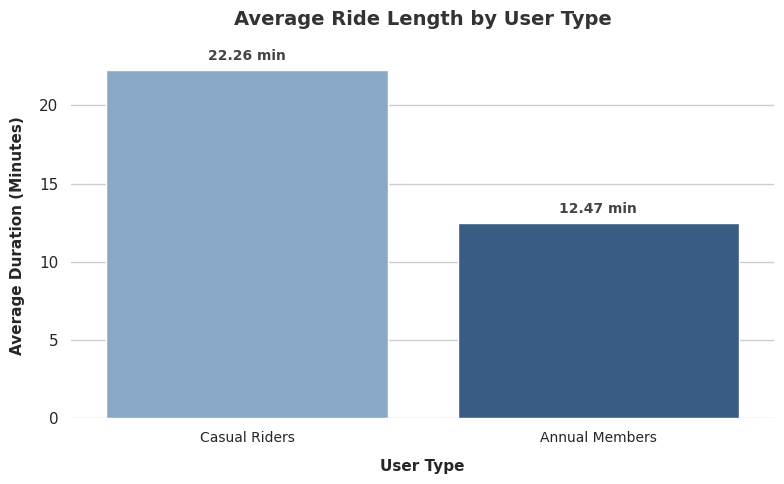


[INFO] Chart generated successfully and saved locally as 'average_duration_visualization.png'


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. DATA PREPARATION
# Calculate the mean trip duration in minutes grouped by rider type
avg_ride_length_user = df_cyclistic.groupby('member_casual')['ride_length_mins'].mean().reset_index()

# Sort data descending for better visual structure and ranking
avg_ride_length_user = avg_ride_length_user.sort_values(by='ride_length_mins', ascending=False)

# 2. PLOT AESTHETICS CONFIGURATION
# Set a clean and modern white grid style
sns.set_theme(style="whitegrid")

# Define figure dimensions (Width x Height)
fig, ax = plt.subplots(figsize=(8, 5))

# Create the bar chart using corporate colors (Dark Blue and Light Blue)
colors = ['#7fa9d1', '#2b5c8f']
bars = sns.barplot(
    x='member_casual',
    y='ride_length_mins',
    data=avg_ride_length_user,
    palette=colors,
    ax=ax,
    hue='member_casual', # Maintained for compatibility with recent Seaborn versions
    legend=False
)

# 3. LABELS, TITLES, AND AXES CUSTOMIZATION
# Main title with visual hierarchy and padding
ax.set_title('Average Ride Length by User Type', fontsize=14, fontweight='bold', pad=20, color='#333333')

# Customize axes labels
ax.set_xlabel('User Type', fontsize=11, fontweight='semibold', labelpad=10)
ax.set_ylabel('Average Duration (Minutes)', fontsize=11, fontweight='semibold', labelpad=10)

# Format X-axis labels to match corporate reporting definitions
ax.set_xticklabels(['Casual Riders', 'Annual Members'], fontsize=10)

# Remove top and right borders for a modern, clean look (despined)
sns.despine(left=True, bottom=True)

# 4. ADD DATA LABELS ON TOP OF BARS
# Dynamically add the precise numeric values above each bar
for bar in bars.patches:
    height = bar.get_height()
    ax.annotate(
        f'{height:.2f} min',                        # Text string (formatted to 2 decimals)
        xy=(bar.get_x() + bar.get_width() / 2, height), # Position coordinates (X, Y)
        xytext=(0, 5),                             # Vertical offset (5 points up)
        textcoords="offset points",
        ha='center', va='bottom',                  # Horizontal and vertical alignment
        fontsize=10, fontweight='bold', color='#444444'
    )

# Adjust plot layout to prevent text clipping upon saving
plt.tight_layout()

# 5. IMAGE SAVING PROMPT FOR GITHUB
# Export the figure to a high-density PNG file (300 DPI) for your README.md
output_image_name = 'average_duration_visualization.png'
plt.savefig(output_image_name, dpi=300, bbox_inches='tight')

# Display final visualization in the Colab notebook environment
plt.show()

print(f"\n[INFO] Chart generated successfully and saved locally as '{output_image_name}'")

### **Business Interpretation**

> The data reveals that the average ride duration is significantly higher for casual riders (22.26 minutes), almost double the duration of annual members (12.47 minutes). This strong contrast suggests that casual users primarily utilize the service for leisure and recreational activities, whereas annual members rely on the bikes for shorter, routine commutes to specific, frequent destinations.

## **2. Calculate the average trip duration for users by day of the week**

/tmp/ipykernel_789/3823938577.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, fontsize=10)


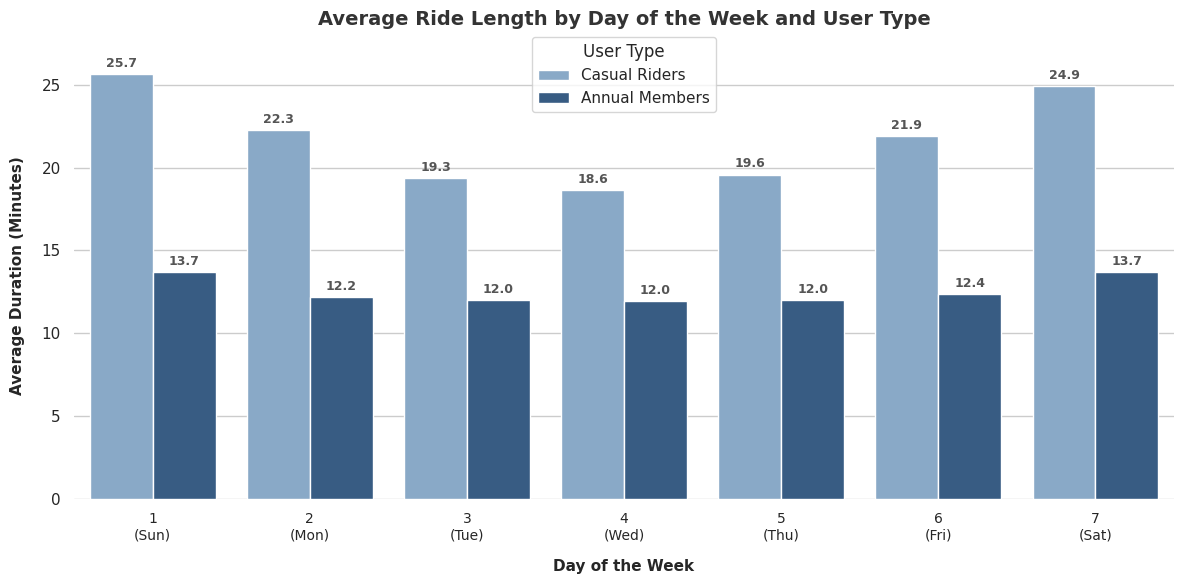


[INFO] Chart generated successfully and saved as 'display_duration_per_day.png'


In [8]:
# 1. DATA PREPARATION & AGGREGATION
# Group by day name and user type to calculate the average ride length in minutes
df_days = df_cyclistic.groupby(['day_name', 'member_casual'])['ride_length_mins'].mean().reset_index()

# Map the English day names to the guide's standard numeric index and short labels
day_mapping = {
    'Sunday': (1, 'Sun'),
    'Monday': (2, 'Mon'),
    'Tuesday': (3, 'Tue'),
    'Wednesday': (4, 'Wed'),
    'Thursday': (5, 'Thu'),
    'Friday': (6, 'Fri'),
    'Saturday': (7, 'Sat')
}

# Assign the numeric sort order and the short name representation
df_days['day_num'] = df_days['day_name'].map(lambda x: day_mapping[x][0])
df_days['day_short'] = df_days['day_name'].map(lambda x: day_mapping[x][1])

# Sort the DataFrame strictly by the numeric day value (1 to 7) for proper chronological rendering
df_days = df_days.sort_values(by='day_num')

# 2. PLOT AESTHETICS CONFIGURATION
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))

# Consistent corporate colors (Dark Blue for annual members, Light Blue for casuals)
colors_palette = {'member': '#2b5c8f', 'casual': '#7fa9d1'}

# Create the grouped bar chart using 'day_num' to enforce numerical sequence on X-axis
sns.barplot(
    x='day_name',
    y='ride_length_mins',
    hue='member_casual',
    data=df_days,
    palette=colors_palette,
    ax=ax
)

# 3. LABELS, TITLES, AND LEGEND CUSTOMIZATION
# Set main title with appropriate visual hierarchy and spacing
ax.set_title('Average Ride Length by Day of the Week and User Type',
             fontsize=14, fontweight='bold', pad=20, color='#333333')

ax.set_xlabel('Day of the Week', fontsize=11, fontweight='semibold', labelpad=12)
ax.set_ylabel('Average Duration (Minutes)', fontsize=11, fontweight='semibold', labelpad=12)

# Generate X-axis labels pairing the day index with its short name
sorted_days = sorted(day_mapping.values(), key=lambda item: item[0])
x_labels = [f"{num}\n({short})" for num, short in sorted_days]
ax.set_xticklabels(x_labels, fontsize=10)

# Synchronize the color handles with formal English labels
handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=['Casual Riders', 'Annual Members'],
    title='User Type',
    loc='lower center',
    bbox_to_anchor=(0.5, 0.85),
    frameon=True
)

# Remove unnecessary spine borders for a cleaner look
sns.despine(left=True, bottom=True)

# 4. ADD DATA LABELS ON TOP OF EACH BAR
# Iterate over the generated bars to place the exact duration value above each one
for bar in ax.patches:
    height = bar.get_height()
    if height > 0: # Check to avoid rendering labels for null or empty bars
        ax.annotate(
            f'{height:.1f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3), # 3 points of vertical offset
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#555555'
        )

plt.tight_layout()

# 5. VISUALIZATION EXPORT
output_image_days = 'display_duration_per_day.png'
plt.savefig(output_image_days, dpi=300, bbox_inches='tight')

plt.show()

print(f"\n[INFO] Chart generated successfully and saved as '{output_image_days}'")

### **Business Interpretation**

> The chart indicates that casual riders have a highly variable average ride duration throughout the week, ranging from 18.6 to 25.7 minutes. There is a clear spike on weekends—peaking at 24.9 minutes on Saturdays and 25.7 minutes on Sundays—which strongly supports the premise that these users utilize the service for recreational rides on their days off.
>
> In contrast, annual members exhibit a much more stable pattern, maintaining a tight duration range between 12.0 and 13.7 minutes. Although members also show a slight increase in ride length during the weekend, their overall consistency confirms that their primary behavior is focused on routine, point-to-point commuting rather than extended leisure.

## **3. Calculate the number of user trips per day of the week by adding the trip ID count to Values**

/tmp/ipykernel_789/2940154237.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, fontsize=10)


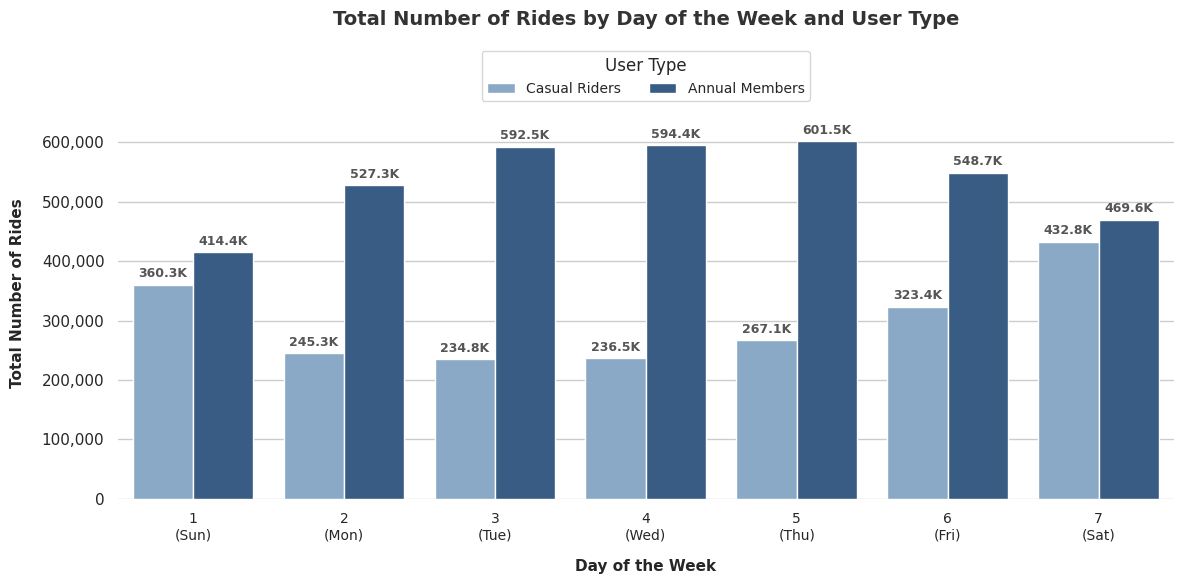


[INFO] Total rides count chart generated successfully and saved as 'visualization_number_of_trips_per_day.png'


In [9]:
# 1. DATA PREPARATION & AGGREGATION (VOLUME COUNT)
# Group by day name and user type, counting the total number of unique 'ride_id' records
df_counts = df_cyclistic.groupby(['day_name', 'member_casual'])['ride_id'].count().reset_index()

# Rename the column for analytical clarity
df_counts.rename(columns={'ride_id': 'total_rides'}, inplace=True)

# Map the English day names to the guide's standard numeric index and short labels
# Standard: 1 = Sunday (Sun), 2 = Monday (Mon), ..., 7 = Saturday (Sat)
day_mapping = {
    'Sunday': (1, 'Sun'),
    'Monday': (2, 'Mon'),
    'Tuesday': (3, 'Tue'),
    'Wednesday': (4, 'Wed'),
    'Thursday': (5, 'Thu'),
    'Friday': (6, 'Fri'),
    'Saturday': (7, 'Sat')
}

# Assign the numeric sort order and the short name representation
df_counts['day_num'] = df_counts['day_name'].map(lambda x: day_mapping[x][0])
df_counts['day_short'] = df_counts['day_name'].map(lambda x: day_mapping[x][1])

# Sort the DataFrame strictly by the numeric day value (1 to 7) for proper chronological rendering
df_counts = df_counts.sort_values(by='day_num')

# 2. PLOT AESTHETICS CONFIGURATION
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))

# Maintain portfolio color consistency (Dark Blue for members, Light Blue for casuals)
colors_palette = {'member': '#2b5c8f', 'casual': '#7fa9d1'}

# Create the grouped bar chart using 'day_num' to enforce numerical sequence on X-axis
sns.barplot(
    x='day_num',
    y='total_rides',
    hue='member_casual',
    data=df_counts,
    palette=colors_palette,
    ax=ax
)

# 3. LABELS, TITLES, AND LEGEND CUSTOMIZATION (PREVENT OVERLAPPING)
# Main title with safety padding to leave space for the legend underneath
ax.set_title('Total Number of Rides by Day of the Week and User Type',
             fontsize=14, fontweight='bold', pad=45, color='#333333')

ax.set_xlabel('Day of the Week', fontsize=11, fontweight='semibold', labelpad=12)
ax.set_ylabel('Total Number of Rides', fontsize=11, fontweight='semibold', labelpad=12)

# Generate X-axis labels pairing the day index with its short name
sorted_days = sorted(day_mapping.values(), key=lambda item: item[0])
x_labels = [f"{num}\n({short})" for num, short in sorted_days]
ax.set_xticklabels(x_labels, fontsize=10)

# Format the Y-axis to display numbers with thousands separators
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Dynamically adjust the Y-axis limit to give a 15% headroom for data labels
max_y_limit = df_counts['total_rides'].max()
ax.set_ylim(0, max_y_limit * 1.15)

# Place the legend in the intermediate space (below the title, above the bars)
handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=['Casual Riders', 'Annual Members'],
    title='User Type',
    loc='lower center',
    bbox_to_anchor=(0.5, 0.95),  # Adjusted safely to avoid overlapping any bar or title
    ncol=2,
    frameon=True,
    fontsize=10
)

# Allocate top margin space so the layout elements are not cut off when saved
plt.subplots_adjust(top=0.85)

# Remove unnecessary spine borders for a modern look
sns.despine(left=True, bottom=True)

# 4. ADD DATA LABELS IN AN EFFICIENT FORMAT (E.G., 245.3K)
# Iterate over the bars to draw the simplified text tags (in thousands "K")
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        # Convert raw counts to thousands format with one decimal place
        label_thousands = f'{height/1000:.1f}K' if height >= 1000 else f'{int(height)}'

        ax.annotate(
            label_thousands,
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3), # 3 points of vertical offset
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#555555'
        )

plt.tight_layout()

# 5. VISUALIZATION EXPORT
output_image_counts = 'visualization_number_of_trips_per_day.png'
plt.savefig(output_image_counts, dpi=300, bbox_inches='tight')

plt.show()

print(f"\n[INFO] Total rides count chart generated successfully and saved as '{output_image_counts}'")

### **Business Interpretation**

> The visualization clearly demonstrates that annual members register a significantly higher volume of trips from Monday to Friday compared to occasional users. However, this considerable difference in volume is drastically reduced over the weekend. On Saturdays and Sundays, the number of occasional users approaches that of members, confirming that the latter dominate the daily commute market, while occasional users considerably narrow the trip gap on weekends.

## **4. At what times of day do the different types of users tend to travel?**

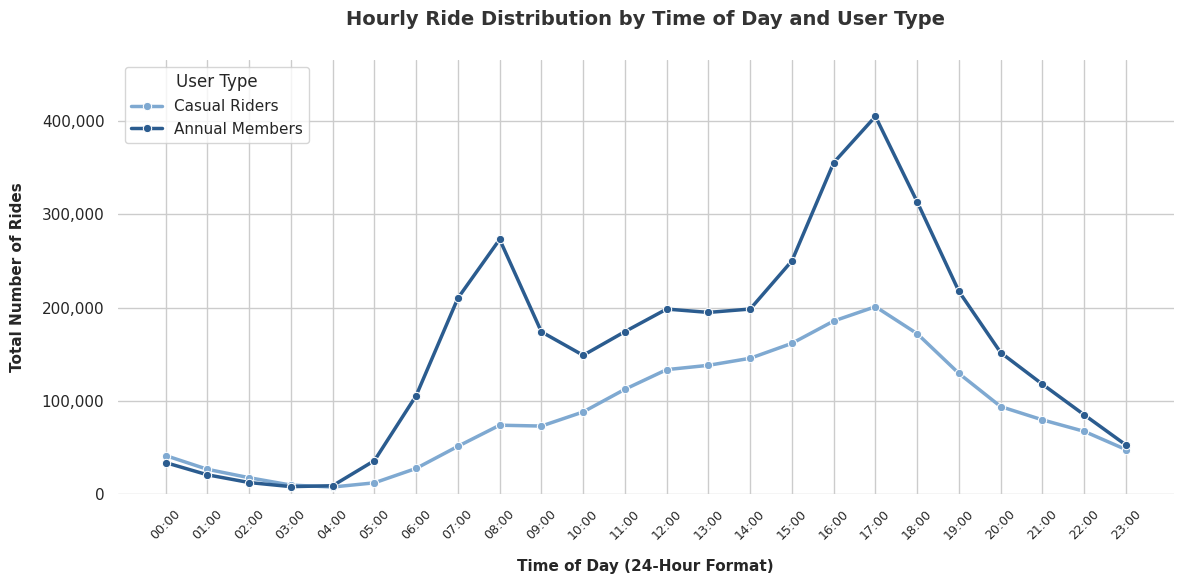


[INFO] Hourly line chart generated successfully and saved as 'visualization_trips_per_hour.png'


In [10]:
# 1. DATA PREPARATION & AGGREGATION (HOURLY DISTRIBUTION)
# Group by the 'hour_of_day' and 'member_casual' columns, counting the total trips
df_hours = df_cyclistic.groupby(['hour_of_day', 'member_casual'])['ride_id'].count().reset_index()

# Rename the count column for analytical clarity
df_hours.rename(columns={'ride_id': 'total_rides'}, inplace=True)

# 2. PLOT AESTHETICS CONFIGURATION (LINE CHART)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))

# Maintain corporate color consistency for your portfolio
colors_palette = {'member': '#2b5c8f', 'casual': '#7fa9d1'}

# Create the line plot
# We use marker="o" to clearly highlight each hourly data point
sns.lineplot(
    x='hour_of_day',
    y='total_rides',
    hue='member_casual',
    data=df_hours,
    palette=colors_palette,
    linewidth=2.5,
    marker='o',
    markersize=6,
    ax=ax
)

# 3. LABELS, TITLES, AND LEGEND CUSTOMIZATION
# Title with adequate padding to prevent visual crowding
ax.set_title('Hourly Ride Distribution by Time of Day and User Type',
             fontsize=14, fontweight='bold', pad=25, color='#333333')

ax.set_xlabel('Time of Day (24-Hour Format)', fontsize=11, fontweight='semibold', labelpad=12)
ax.set_ylabel('Total Number of Rides', fontsize=11, fontweight='semibold', labelpad=12)

# Force the X-axis to display every single hour (0 to 23) as a time string
ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45, fontsize=9)

# Format the Y-axis to display numbers with thousands separators
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Adjust the Y-axis limit by adding a 15% headroom for a clean layout
max_y_limit = df_hours['total_rides'].max()
ax.set_ylim(0, max_y_limit * 1.15)

# SYNCED LEGEND: Map clean English labels to the automatic color handles
handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=['Casual Riders', 'Annual Members'],
    title='User Type',
    loc='upper left',
    frameon=True
)

# Remove unnecessary spine borders for a modern look
sns.despine(left=True, bottom=True)

plt.tight_layout()

# 4. VISUALIZATION EXPORT
output_image_hours = 'visualization_trips_per_hour.png'
plt.savefig(output_image_hours, dpi=300, bbox_inches='tight')

plt.show()

print(f"\n[INFO] Hourly line chart generated successfully and saved as '{output_image_hours}'")

### **Business Interpretation**

> This chart illustrates that annual members rely heavily on the bike-share system for routine daily commuting. Their distribution displays a classic bimodal pattern with sharp peaks at 08:00 AM and 05:00 PM (17:00), matching traditional office rush hours, with the evening rush registering the absolute highest volume of the day.
>
> In contrast, casual riders exhibit a different behavioral curve. They do not share the morning commuting spike at 08:00 AM; instead, their ridership builds up gradually throughout the day, forming a smooth curve that peaks in the late afternoon. This underscores that while members use the service as a strict utility tool for work schedules, casual usage is driven by afternoon leisure and flexible personal trips.

## **5. At which station do non-member users begin and end their journeys?**

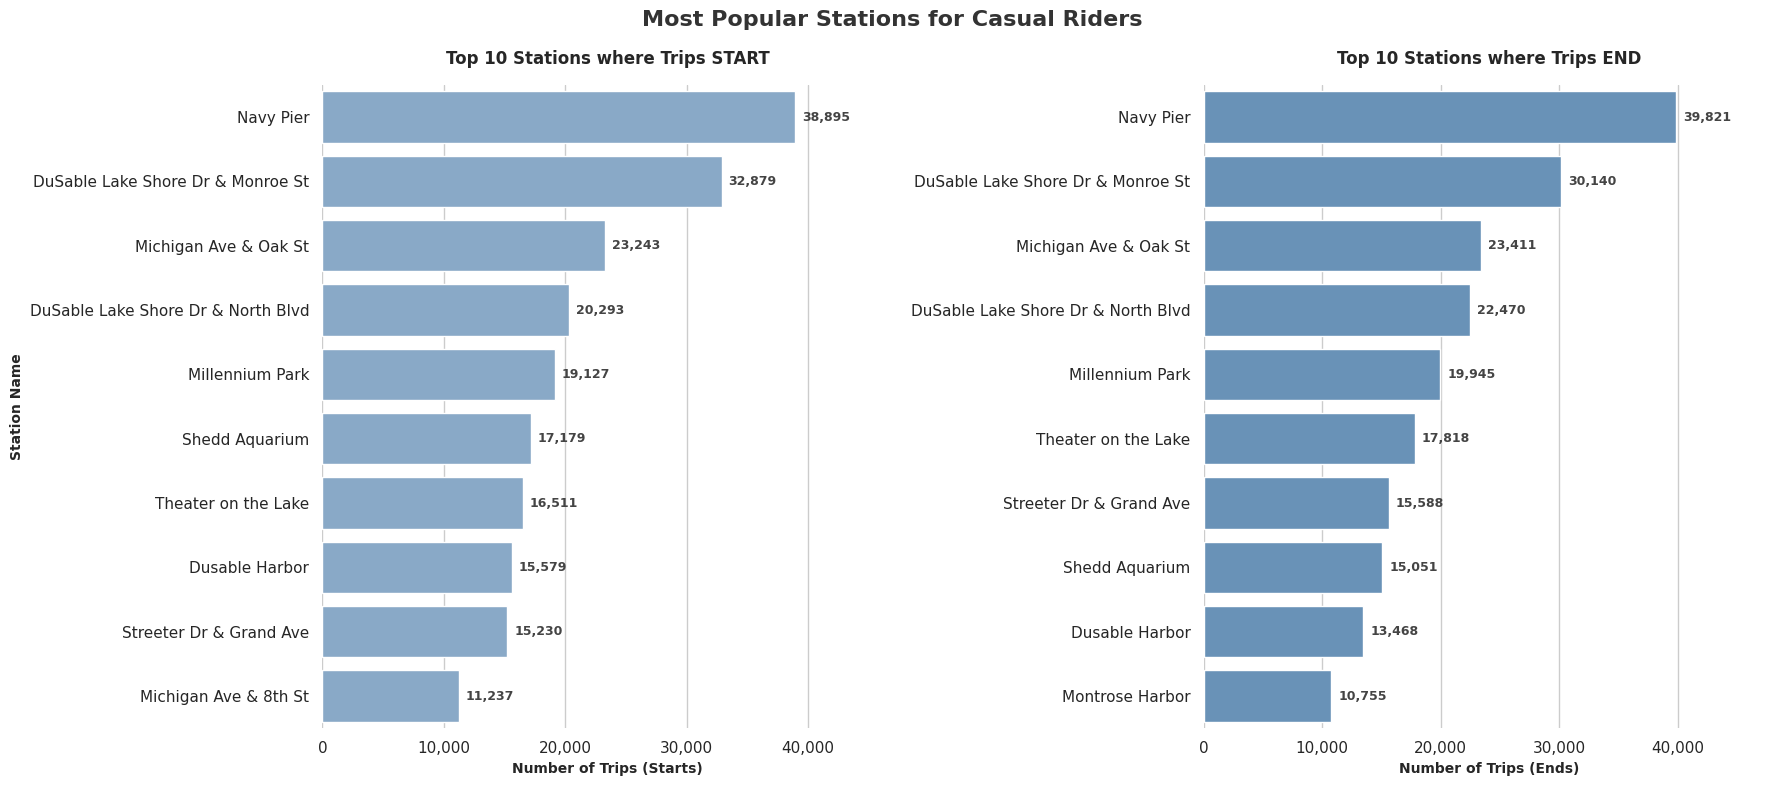


[INFO] Comparative station chart generated successfully and saved as 'visualization_of_casual_stations.png'


In [11]:
# 1. DATA FILTERING & PREPARATION (CASUAL RIDERS ONLY)
# Filter to work exclusively with casual riders
df_casual = df_cyclistic[df_cyclistic['member_casual'] == 'casual'].copy()

# Drop rows where station names are null (missing values)
df_casual_start = df_casual.dropna(subset=['start_station_name'])
df_casual_end = df_casual.dropna(subset=['end_station_name'])

# Retrieve Top 10 START stations
top10_start = df_casual_start['start_station_name'].value_counts().head(10).reset_index()
top10_start.columns = ['station_name', 'ride_count']

# Retrieve Top 10 END stations
top10_end = df_casual_end['end_station_name'].value_counts().head(10).reset_index()
top10_end.columns = ['station_name', 'ride_count']

# 2. CANVAS CONFIGURATION (SUBPLOTS: 1 ROW, 2 COLUMNS)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))

# Corporate brand colors for casual users
color_casual_start = '#7fa9d1'
color_casual_end = '#5c93c4'  # Slightly darker tone for visual differentiation

# PLOT 1: TOP 10 START STATIONS
sns.barplot(
    x='ride_count',
    y='station_name',
    data=top10_start,
    color=color_casual_start,
    ax=axes[0]
)

axes[0].set_title('Top 10 Stations where Trips START', fontsize=12, fontweight='bold', pad=15)
axes[0].set_xlabel('Number of Trips (Starts)', fontsize=10, fontweight='semibold')
axes[0].set_ylabel('Station Name', fontsize=10, fontweight='semibold')
axes[0].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Draw data labels at the end of each horizontal bar
for bar in axes[0].patches:
    width = bar.get_width()
    axes[0].annotate(
        f'{int(width):,}',
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha='left', va='center',
        fontsize=9, fontweight='bold', color='#444444'
    )

# PLOT 2: TOP 10 END STATIONS
sns.barplot(
    x='ride_count',
    y='station_name',
    data=top10_end,
    color=color_casual_end,
    ax=axes[1]
)

axes[1].set_title('Top 10 Stations where Trips END', fontsize=12, fontweight='bold', pad=15)
axes[1].set_xlabel('Number of Trips (Ends)', fontsize=10, fontweight='semibold')
axes[1].set_ylabel('', labelpad=0) # Omit Y-label to avoid crowding the central layout space
axes[1].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Draw data labels at the end of each horizontal bar
for bar in axes[1].patches:
    width = bar.get_width()
    axes[1].annotate(
        f'{int(width):,}',
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha='left', va='center',
        fontsize=9, fontweight='bold', color='#444444'
    )

# 3. FINAL ADJUSTMENTS & EXPORT
# Global super-title for the figure
plt.suptitle('Most Popular Stations for Casual Riders',
             fontsize=16, fontweight='bold', y=0.98, color='#333333')

# Dynamically scale X-axis limits to prevent text labels from being cropped
for ax in axes:
    current_limit = ax.get_xlim()[1]
    ax.set_xlim(0, current_limit * 1.15)
    sns.despine(ax=ax, left=True, bottom=True)

plt.tight_layout()

# Save the high-resolution visualization for your GitHub repository
output_image_stations = 'visualization_of_casual_stations.png'
plt.savefig(output_image_stations, dpi=300, bbox_inches='tight')

plt.show()

print(f"\n[INFO] Comparative station chart generated successfully and saved as '{output_image_stations}'")

### **Business Interpretation**

> The data reveals a strong symmetry between the locations where casual riders choose to both start and end their journeys. The most heavily trafficked hubs are **Navy Pier**, **DuSable Lake Shore Dr & Monroe St**, **Michigan Ave & Oak St**, **DuSable Lake Shore Dr & North Blvd**, and **Millennium Park**. Geographically, all of these top stations correspond to iconic tourist landmarks, waterfront paths, and major public parks. This clearly confirms that non-members concentrate their activity around leisure and sightseeing hotspots rather than commercial or residential transit corridors.

## **6. Comparative analysis of monthly ridership distribution by user type**

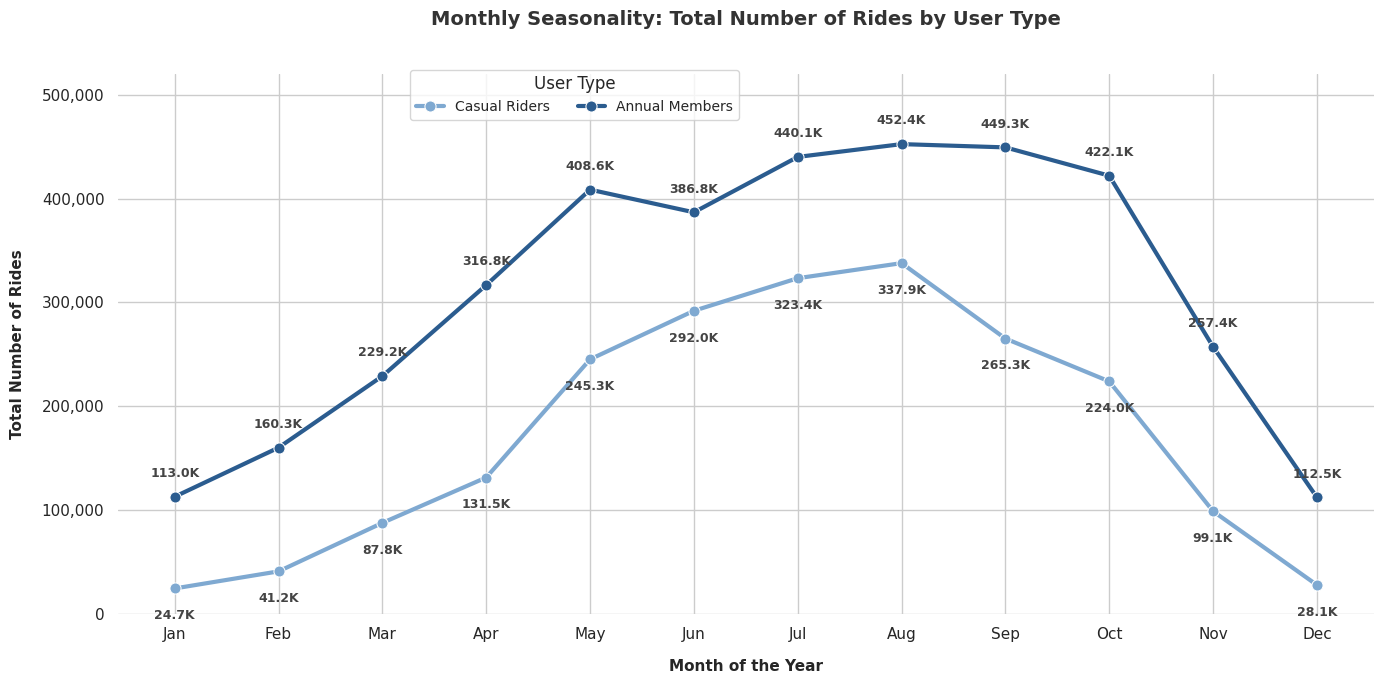


[INFO] Monthly trend comparative chart generated successfully and saved as 'visualization_trips_per_month_comparison.png'


In [12]:
# 1. DATA PREPARATION & AGGREGATION (CHRONOLOGICAL)
# Group by BOTH month and user type to count the total number of rides
df_months_count = df_cyclistic.groupby(['month_name', 'member_casual'])['ride_id'].count().reset_index()
df_months_count.rename(columns={'ride_id': 'total_rides'}, inplace=True)

# Mapping dictionary to order months chronologically and set short labels
month_mapping = {
    'January': (1, 'Jan'), 'February': (2, 'Feb'), 'March': (3, 'Mar'),
    'April': (4, 'Apr'), 'May': (5, 'May'), 'June': (6, 'Jun'),
    'July': (7, 'Jul'), 'August': (8, 'Aug'), 'September': (9, 'Sep'),
    'October': (10, 'Oct'), 'November': (11, 'Nov'), 'December': (12, 'Dec')
}

# Map the sorting order index and the English short name representation
df_months_count['month_num'] = df_months_count['month_name'].map(lambda x: month_mapping[x][0])
df_months_count['month_short'] = df_months_count['month_name'].map(lambda x: month_mapping[x][1])

# Enforce strict chronological sorting
df_months_count = df_months_count.sort_values(by=['month_num', 'member_casual'])

# 2. PLOT AESTHETICS CONFIGURATION (EVOLUTIVE LINE CHART)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 7))

# Brand color matching for both user types to maintain portfolio consistency
colors_palette = {'member': '#2b5c8f', 'casual': '#7fa9d1'}

# Create the monthly trend line plot for BOTH users using the 'hue' parameter
sns.lineplot(
    x='month_short',
    y='total_rides',
    hue='member_casual',
    data=df_months_count,
    palette=colors_palette,
    marker='o',
    markersize=8,
    linewidth=3,
    sort=False, # Prevents Seaborn from alphabetically re-sorting our X-axis categories
    ax=ax
)

# 3. LABELS, TITLES, AND AXES CUSTOMIZATION
ax.set_title('Monthly Seasonality: Total Number of Rides by User Type',
             fontsize=14, fontweight='bold', pad=35, color='#333333')

ax.set_xlabel('Month of the Year', fontsize=11, fontweight='semibold', labelpad=12)
ax.set_ylabel('Total Number of Rides', fontsize=11, fontweight='semibold', labelpad=12)

# Format the Y-axis to display numbers with thousands separators
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Set Y-axis margins dynamically and start at 0 to ensure fair visual proportion
max_month_rides = df_months_count['total_rides'].max()
ax.set_ylim(0, max_month_rides * 1.15)

# Add Legend securely placed at the top to avoid overlapping with the lines
handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=['Casual Riders', 'Annual Members'],
    title='User Type',
    loc='upper right',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=True,
    fontsize=10
)
plt.subplots_adjust(top=0.85)

# 4. ADD DATA LABELS ON KEY SEASONAL POINTS
# Iterate over each monthly data point to draw clean 'K' (thousands) formatted labels
for i, row in df_months_count.iterrows():
    val = row['total_rides']
    label_k = f'{val/1000:.1f}K' if val >= 1000 else f'{int(val)}'

    # Conditional logic to prevent label collision:
    # Member labels float above the marker, Casual labels float slightly below
    y_offset = 12 if row['member_casual'] == 'member' else -15
    v_align = 'bottom' if row['member_casual'] == 'member' else 'top'

    ax.annotate(
        label_k,
        xy=(row['month_short'], val),
        xytext=(0, y_offset),
        textcoords="offset points",
        ha='center', va=v_align,
        fontsize=9, fontweight='bold', color='#444444'
    )

# Remove unnecessary borders for a cleaner presentation
sns.despine(left=True, bottom=True)
plt.tight_layout()

# 5. VISUALIZATION EXPORT
output_image_months = 'visualization_trips_per_month_comparison.png'
plt.savefig(output_image_months, dpi=300, bbox_inches='tight')

plt.show()

print(f"\n[INFO] Monthly trend comparative chart generated successfully and saved as '{output_image_months}'")

### **Business Interpretation**

> The visualization displays a significant growth trend during the summer season, with **August** recording the absolute peak at **337.9K** rides for casual users and **452.4K** for annual members. A key takeaway from this comparison is that both user groups exhibit highly similar behavior throughout the year, with their ridership curves moving in parallel as volume expands during the warmer months.
>
> This shared surge is heavily driven by favorable weather conditions ideal for outdoor cycling, alongside traditional summer vacation periods. Conversely, ridership for both categories drops dramatically at the beginning and end of the year. This sharp decline aligns with Chicago's severe winter conditions and the resumption of academic and corporate schedules, though the more drastic percentage drop in casual users reinforces the purely recreational nature of non-member usage compared to the baseline utility of annual members.

# <font color='439ADF'> **4. Recommendations** </font>

### **Strategic Marketing Recommendations for Lily Moreno**

Based on the evidence uncovered throughout this analysis, the marketing team should focus resources on the following three data-driven strategies to maximize the conversion of casual riders into annual members:

#### **1. Frame the Annual Membership as a "Health & Recreational Asset"**
* **Action:** Launch marketing campaigns specifically tailored around fitness, outdoor recreation, and urban tourism. The messaging should emphasize the physical and mental health benefits of regular cycling, targeted at the lifestyle of casual users.
* **Data-Driven Justification:** Casual riders log an average trip duration that is more than double that of annual members (22.26 vs. 12.47 minutes). This proves they view the service as an active leisure vehicle. The campaign should position the annual membership as the most cost-effective and seamless way to sustain a healthy, recreational lifestyle year-round.

#### **2. Execute Time-Targeted Digital & Social Media Campaigns (High-Season Micro-Targeting)**
* **Action:** Concentrate marketing spend and campaign rollouts heavily during the summer season, focusing digital placements strictly on weekends (Saturdays and Sundays) and during peak afternoon hours. Utilize dynamic visual ads on social media and geotargeted mobile banners that resonate with consumers who are actively on the move.
* **Data-Driven Justification:** Casual ridership experiences an explosive surge during June, July, and August—peaking at 337.9K rides in August—with usage highly concentrated on weekends and throughout the afternoon cycle (12:00 PM to 5:00 PM). Deploying assets during these precise temporal windows guarantees maximum reach and conversion potential among high-intent casual users.

#### **3. Prioritize Hyper-Local Activation at Top Casual Transit Hubs**
* **Action:** Deploy high-visibility out-of-home (OOH) advertisements, physical posters, QR-code conversion checkpoints, and brand ambassadors at Cyclistic’s highest-volume stations.
* **Data-Driven Justification:** The geographical footprint reveals that non-member traffic is heavily clustered around specific waterfront paths, public parks, and cultural landmarks. Marketing efforts must be aggressively localized at the **Top 5 Casual Stations**:
  1. *Navy Pier*
  2. *DuSable Lake Shore Dr & Monroe St*
  3. *Michigan Ave & Oak St*
  4. *DuSable Lake Shore Dr & North Blvd*
  5. *Millennium Park*